# Population-Based Training for XGBoost — Demo

This notebook evolves **XGBoost classifier** hyperparameters with `pbt_xgb`, a genetic algorithm
built on general evolutionary principles.

A **population** of models, each with a **genome** (hyperparameters) and a **phenotype** (its
warm-started booster), is improved over **generations** through five stages:

1. **Evaluate fitness** — grow each member a few boosting rounds, score on a validation set.
2. **Selection** — the fittest `selection_top_k` survive (elitism).
3. **Crossover** — offspring recombine genes from two parents; the **dominant** (fitter) parent
   contributes each gene with probability `dominance_prob`, and the child inherits its booster.
4. **Mutation** — a fraction of genes are perturbed.
5. **Stopping** — at `generations`, or early on `target_fitness` / `patience` plateau.

Models are trained **only** on the training set; fitness is measured **only** on the validation set.

In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

from pbt_xgb import PopulationBasedTraining

## 1. Data

A synthetic binary classification problem, split into **train** (fit boosters), **validation**
(drives fitness/selection), and a held-out **test** set (final, unbiased evaluation).

In [2]:
X, y = make_classification(
    n_samples=2000, n_features=20, n_informative=10, n_classes=2, random_state=0
)
X = X.astype(np.float32)

X_tmp, X_test, y_tmp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_tmp, y_tmp, test_size=0.25, random_state=0, stratify=y_tmp
)
print(f"train={X_train.shape}  val={X_val.shape}  test={X_test.shape}")

train=(1200, 20)  val=(400, 20)  test=(400, 20)


## 2. Configure and run PBT

We optimize **validation log-loss** (lower is better). The population is evaluated in parallel via
joblib (`n_jobs=-1`).

In [3]:
pbt = PopulationBasedTraining(
    population_size=12,
    metric="logloss",        # logloss | accuracy | roc_auc | f1 | average_precision | callable
    selection_top_k=4,       # survivors per generation
    dominance_prob=0.7,      # crossover: dominant-parent gene probability
    mutation_fraction=0.3,   # fraction of genes mutated
    mutation_intensity=0.2,  # mutation magnitude
    generations=12,          # max generations ("epochs")
    step_rounds=10,          # boosting rounds added per generation
    n_jobs=-1,
    random_state=0,
)
pbt.fit(X_train, y_train, X_val, y_val)
print(f"best validation logloss: {pbt.best_score_:.5f}")

best validation logloss: 0.25444


## 3. Evolution of fitness across generations

The best validation fitness should improve (here, log-loss should fall) as the population adapts.

In [4]:
best_per_gen = pbt.history_.groupby("generation")["score"].min()
best_per_gen

generation
0     0.360101
1     0.316737
2     0.309618
3     0.293055
4     0.277774
5     0.271191
6     0.268421
7     0.263445
8     0.262251
9     0.256995
10    0.254438
11    0.254811
Name: score, dtype: float64

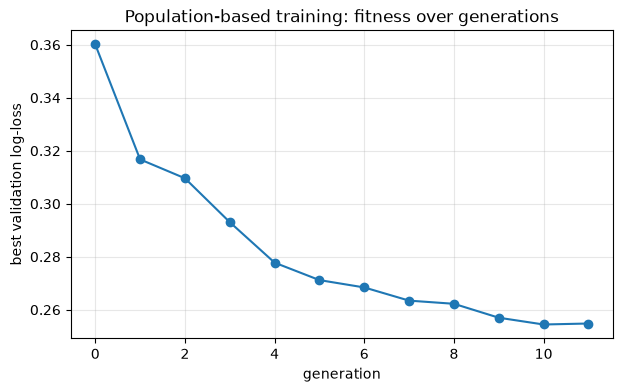

In [5]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(best_per_gen.index, best_per_gen.values, marker="o")
ax.set_xlabel("generation")
ax.set_ylabel("best validation log-loss")
ax.set_title("Population-based training: fitness over generations")
ax.grid(True, alpha=0.3)
plt.show()

## 4. The fittest individual

`best_params_` is the genome of the best model found.

In [6]:
print(f"best_score_ (validation logloss): {pbt.best_score_:.5f}")
pd.Series(pbt.best_params_, name="value").to_frame()

best_score_ (validation logloss): 0.25444


,value
learning_rate,0.253048
max_depth,9.000000
min_child_weight,2.108918
gamma,0.127330
subsample,0.877560
colsample_bytree,0.679302
colsample_bylevel,0.906406
colsample_bynode,0.724665
max_delta_step,2.273014
reg_alpha,0.006669


## 5. Evaluate on the held-out test set

`predict_proba` returns `(n_samples, n_classes)` probabilities; `predict` returns class labels.

In [7]:
proba = pbt.predict_proba(X_test)
preds = pbt.predict(X_test)

print(f"predict_proba shape: {proba.shape}  (n_classes={pbt.n_classes_})")
print(f"rows sum to 1: {np.allclose(proba.sum(axis=1), 1.0)}")
print(f"held-out test accuracy: {accuracy_score(y_test, preds):.4f}")

predict_proba shape: (400, 2)  (n_classes=2)
rows sum to 1: True
held-out test accuracy: 0.8725


## 6. Full evolutionary lineage

`history_` records every individual in every generation, including which parents bred it
(`parents`) — the complete record of the run.

In [8]:
print(f"history_: {len(pbt.history_)} rows "
      f"({pbt.history_['generation'].nunique()} generations x "
      f"{pbt.history_['member_id'].nunique()} members)")
pbt.history_.head(12)

history_: 144 rows (12 generations x 12 members)


,generation,member_id,score,n_rounds,parents,learning_rate,max_depth,min_child_weight,gamma,subsample,colsample_bytree,colsample_bylevel,colsample_bynode,max_delta_step,reg_alpha,reg_lambda
0,0,0,0.569338,10,None,0.037830,5,1.098939,0.082638,0.906635,0.956378,0.803318,0.864748,5.436250,3.023983e-01,2.201314e-01
1,0,1,0.688699,10,None,0.001016,9,1.080402,3.648277,0.587828,0.931589,0.770731,0.649856,4.226872,1.684835e-08,1.313861e-07
2,0,2,0.534298,10,None,0.045837,8,4.124631,1.918388,0.998605,0.990418,0.842771,0.825230,6.884467,1.292324e-05,1.643874e-07
3,0,3,0.485639,10,None,0.061265,7,2.042875,2.429177,0.944744,0.967022,0.678898,0.785765,3.218694,5.680679e-04,1.099515e-05
4,0,4,0.653015,10,None,0.009334,9,1.687165,3.115936,0.542008,0.916322,0.893549,0.619685,8.764842,2.941334e-08,1.059384e-05
5,0,5,0.686805,10,None,0.002356,6,6.256397,1.153211,0.526011,0.702276,0.599257,0.545377,5.803324,2.452274e-06,1.116745e-02
6,0,6,0.677949,10,None,0.003120,10,2.317983,0.527476,0.814554,0.963577,0.720189,0.977295,4.998958,2.522487e-05,3.818749e-03
7,0,7,0.360101,10,None,0.291726,10,2.884331,3.788644,0.748711,0.764656,0.892893,0.707328,7.344836,4.888133e-03,2.446455e+00
8,0,8,0.687519,10,None,0.001926,8,8.461044,4.839631,0.507353,0.931820,0.990598,0.978605,1.487640,6.039911e-01,1.021927e+00
9,0,9,0.468425,10,None,0.108923,6,1.707548,4.009403,0.961765,0.633065,0.769467,0.721376,9.310173,2.109044e-08,3.873074e-02
